# MPO Tensor network

In [146]:
import numpy as np
import qiskit.quantum_info as qi
from processtensor import QTensor, QuantumState, UnitarySE, ProcessTensor
from qiskit.visualization import plot_state_hinton

import quimb.tensor as qtn

In [147]:
dS = 2
dE = 2

dS2 = dS * dS
dE2 = dE * dE
dS4 = dS2 * dS2

unitary = qi.random_unitary(dS * dE)
U = UnitarySE.from_unitary(unitary.data, dS, dE)
# rho_init = qi.random_density_matrix(dE)
rho_init = qi.DensityMatrix(qi.random_statevector(dE))
r = QuantumState.from_matrix(rho_init.data, dE=dE)

U_init = r @ U
U_init = U_init.reshape(1, dS2, dS2, dE2)


In [148]:
A0 = qtn.Tensor(U_init.reshape(dS4, dE2).data, inds=('s0', 'e1'), tags={'left'})
A1 = qtn.Tensor(U.reshape(dE2, dS4, dE2).data, inds=('e1', 's1', 'e2'), tags={'left'})
A2 = qtn.Tensor(U.reshape(dE2, dS4, dE2).data, inds=('e2', 's2', 'e3'), tags={'right'})
A3 = qtn.Tensor(U.trace_subsystem(3).data.reshape(dE2, dS2 * dS2), inds=('e3', 's3'), tags={'right'})

tn = qtn.TensorNetwork([A0, A1, A2, A3])

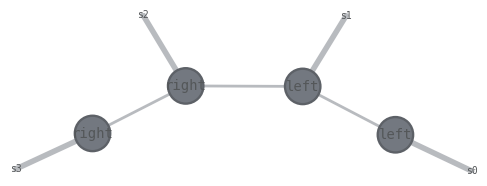

In [149]:
tn.draw()

In [150]:
tn_left = tn.select(['left'])
tn_right = tn.select(['right'])
left = tn_left.contract()
right = tn_right.contract()

In [151]:
M = qtn.tensor_contract(left, right)

In [152]:
M = M.data.reshape(256, 256)

In [153]:
np.linalg.matrix_rank(M) 

np.int64(4)